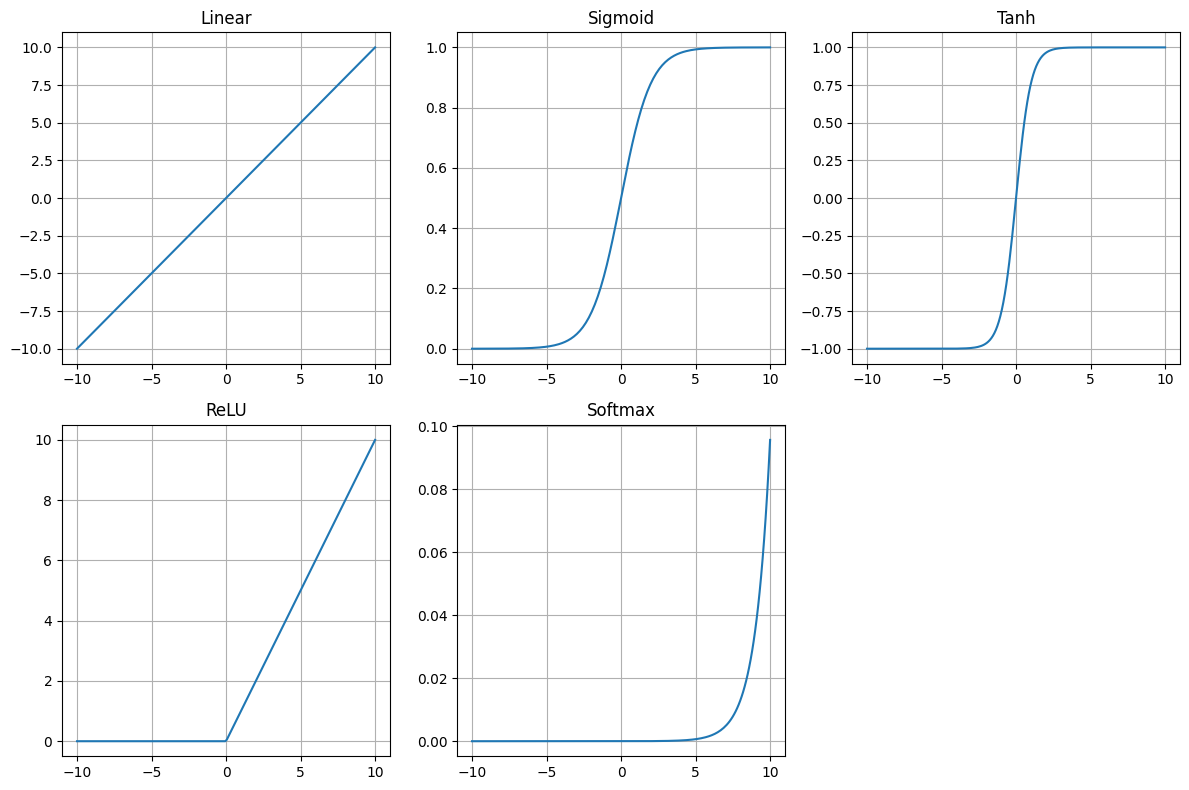

In [ ]:
# Q1. Write a python program to implement and plot the given activation functions of neural networks: Linear, Sigmoid, Tanh, ReLU and Softmax.
import numpy as np
import matplotlib.pyplot as plt


x = np.linspace(-10, 10, 200)

linear = x
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)


exp_x = np.exp(x - np.max(x))
softmax = exp_x / np.sum(exp_x)


plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.plot(x, linear)
plt.title("Linear")
plt.grid(True)

plt.subplot(2,3,2)
plt.plot(x, sigmoid)
plt.title("Sigmoid")
plt.grid(True)

plt.subplot(2,3,3)
plt.plot(x, tanh)
plt.title("Tanh")
plt.grid(True)

plt.subplot(2,3,4)
plt.plot(x, relu)
plt.title("ReLU")
plt.grid(True)

plt.subplot(2,3,5)
plt.plot(x, softmax)
plt.title("Softmax")
plt.grid(True)

plt.tight_layout()
plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8672 - loss: 0.5068 - val_accuracy: 0.9140 - val_loss: 0.3163
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9106 - loss: 0.3178 - val_accuracy: 0.9168 - val_loss: 0.2953
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9177 - loss: 0.2937 - val_accuracy: 0.9247 - val_loss: 0.2767
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9204 - loss: 0.2809 - val_accuracy: 0.9249 - val_loss: 0.2739
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9233 - loss: 0.2734 - val_accuracy: 0.9252 - val_loss: 0.2721
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9249 - loss: 0.2680 - val_accuracy: 0.9291 - val_loss: 0.2632
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9255 - loss: 0.2642 - val_accuracy: 0.9284 - val_loss: 0.2626
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9274 - loss: 0.2603 - 

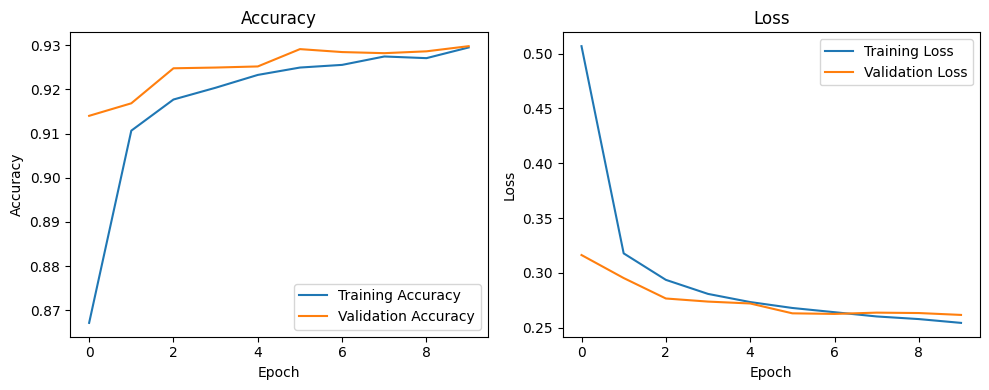

In [ ]:
# Q2. Implement a Single Layer Perceptron using a TensorFlow library and calculate the accuracy of the model on the testing data using the MNIST dataset.
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
import matplotlib.pyplot as plt


(X_train, y_train), (X_test, y_test) = mnist.load_data()


X_train = X_train / 255.0
X_test = X_test / 255.0


model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(10, activation='softmax')
])


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)


loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Q3. Write a python program to implement OR gate using a single layer perceptron learning rule.
import numpy as np


X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,1,1,1])


weights = np.zeros(2)
bias = 0

learning_rate = 0.1
epochs = 10


def activation(net):
    if net >= 0:
        return 1
    return 0


for epoch in range(epochs):
    for i in range(len(X)):
        net = np.dot(X[i], weights) + bias
        output = activation(net)

        error = y[i] - output

        weights = weights + learning_rate * error * X[i]
        bias = bias + learning_rate * error

print("Final Weights:", weights)
print("Final Bias:", bias)

print("\nOR Gate Output")

for i in range(len(X)):
    net = np.dot(X[i], weights) + bias
    prediction = activation(net)
    print(X[i], "->", prediction)

Final Weights: [0.1 0.1]
Final Bias: -0.1

OR Gate Output
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 1


In [ ]:
# Q4. Write a python program to implement AND gate using a single layer perceptron learning rule.
import numpy as np


X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,0,0,1])


weights = np.zeros(2)
bias = 0

learning_rate = 0.1
epochs = 10


def activation(net):
    if net >= 0:
        return 1
    return 0


for epoch in range(epochs):
    for i in range(len(X)):
        net = np.dot(X[i], weights) + bias
        output = activation(net)

        error = y[i] - output

        weights = weights + learning_rate * error * X[i]
        bias = bias + learning_rate * error

print("Final Weights:", weights)
print("Final Bias:", bias)

print("\nAND Gate Output")

for i in range(len(X)):
    net = np.dot(X[i], weights) + bias
    prediction = activation(net)
    print(X[i], "->", prediction)

Final Weights: [0.2 0.1]
Final Bias: -0.20000000000000004

AND Gate Output
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1


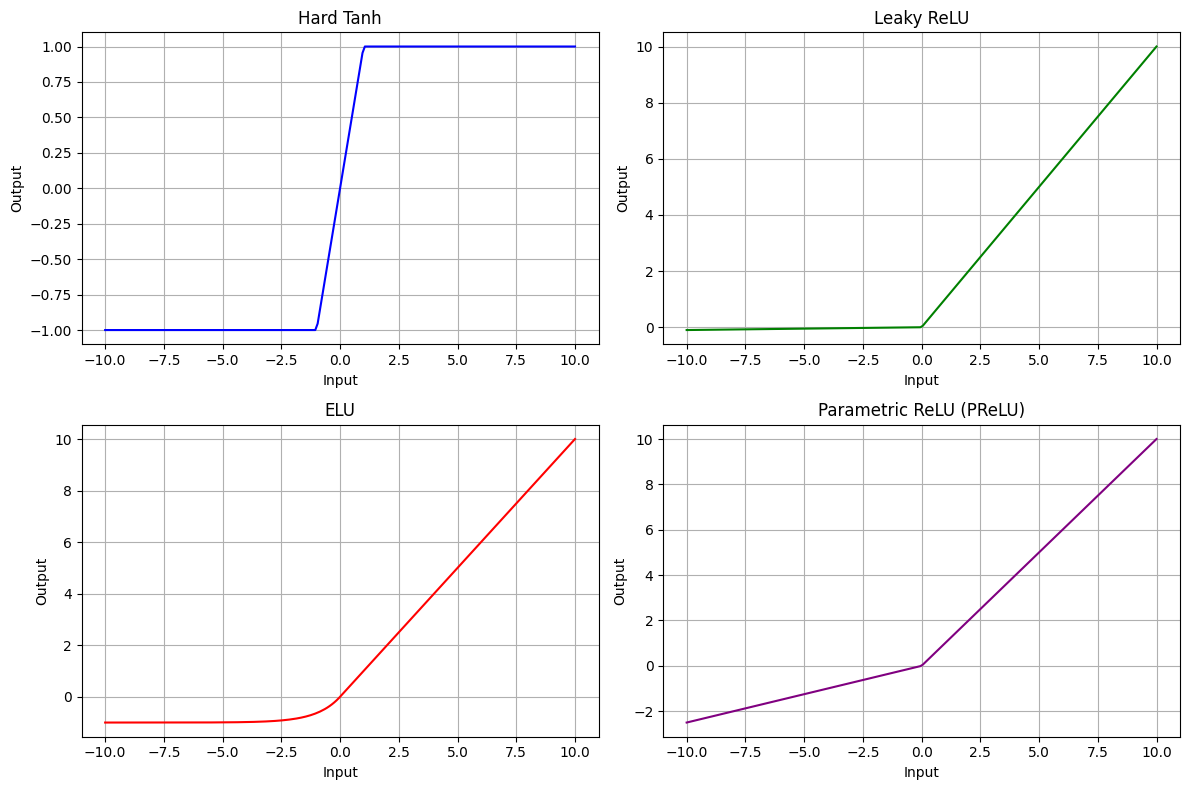

In [ ]:
# Set B - Q1. Write a python program to implement and plot the given activation functions of neural networks: Hard Tanh, Leaky ReLU and ELU.
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 200)

hard_tanh = np.clip(x, -1, 1)

alpha = 0.01
leaky_relu = np.where(x >= 0, x, alpha * x)

alpha = 1.0
elu = np.where(x >= 0, x, alpha * (np.exp(x) - 1))


a = 0.25
prelu = np.where(x >= 0, x, a * x)


plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.plot(x, hard_tanh, color='blue')
plt.title("Hard Tanh")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)

plt.subplot(2,2,2)
plt.plot(x, leaky_relu, color='green')
plt.title("Leaky ReLU")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)

plt.subplot(2,2,3)
plt.plot(x, elu, color='red')
plt.title("ELU")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)

plt.subplot(2,2,4)
plt.plot(x, prelu, color='purple')
plt.title("Parametric ReLU (PReLU)")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Set B - Q2. Write a python program to implement a NAND gate using a single layer perceptron learning rule.
import numpy as np


X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([1,1,1,0])


weights = np.zeros(2)
bias = 0

learning_rate = 0.1
epochs = 10


def activation(net):
    if net >= 0:
        return 1
    return 0


for epoch in range(epochs):
    for i in range(len(X)):
        net = np.dot(X[i], weights) + bias
        output = activation(net)

        error = y[i] - output

        weights = weights + learning_rate * error * X[i]
        bias = bias + learning_rate * error

print("Final Weights:", weights)
print("Final Bias:", bias)

print("\nNAND Gate Output")

for i in range(len(X)):
    net = np.dot(X[i], weights) + bias
    prediction = activation(net)
    print(X[i], "->", prediction)

Final Weights: [-0.2 -0.1]
Final Bias: 0.2

NAND Gate Output
[0 0] -> 1
[0 1] -> 1
[1 0] -> 1
[1 1] -> 0
